# Análise Exploratória de Dados (EDA)

Este notebook apresenta a análise exploratória inicial dos dados textuais fornecidos. O objetivo central é entender as características do dataset, como as distribuições por canal de origem e classes macro/detalhadas, além da volumetria dos chamados e sua estrutura semântica.

Essa análise fundamenta as escolhas feitas no pipeline de NLP (Notebook 02) e na modelagem (Notebook 03).

## 1. Importação das Dependências
Instalaremos as bibliotecas necessárias caso não estejam.

In [ ]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carregamento e Visão Geral dos Dados

In [28]:
df = pd.read_csv('data/dataset.csv')
display(df.head())

,id_registro,texto,canal_origem,data,classe_macro,classe_detalhada
0,1,Erro recorrente no sistema ao tentar acessar d...,sistema,2025-03-08,Problemas Técnicos,Erro de Sistema / Aplicação
1,2,Pedido de integração para sincronização de dados.,email,2025-03-22,Solicitações Operacionais,Integração com Sistemas Externos
2,3,Aguardando posicionamento.,formulario,2025-03-02,Outros,Mensagem Genérica
3,4,O sistema apresentou um erro inesperado ao exe...,chat,2025-03-17,Problemas Técnicos,Erro de Sistema / Aplicação
4,5,Aguardando posicionamento.,chat,2025-03-23,Outros,Mensagem Genérica


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id_registro       1200 non-null   int64
 1   texto             1200 non-null   str  
 2   canal_origem      1200 non-null   str  
 3   data              1200 non-null   str  
 4   classe_macro      1200 non-null   str  
 5   classe_detalhada  1200 non-null   str  
dtypes: int64(1), str(5)
memory usage: 56.4 KB


In [30]:
print(f"Valores Nulos:{df.isnull().sum()}")

Valores Nulos:id_registro         0
texto               0
canal_origem        0
data                0
classe_macro        0
classe_detalhada    0
dtype: int64


In [31]:
print(f"Linhas Duplicadas: {df.duplicated().sum()}")

Linhas Duplicadas: 0


> Identificamos 1200 registros. Importante notar que não há valores nulos e não temos linhas preenchidas como exatas duplicadas em todo o dataframe.

## 3. Distribuições das Categorias

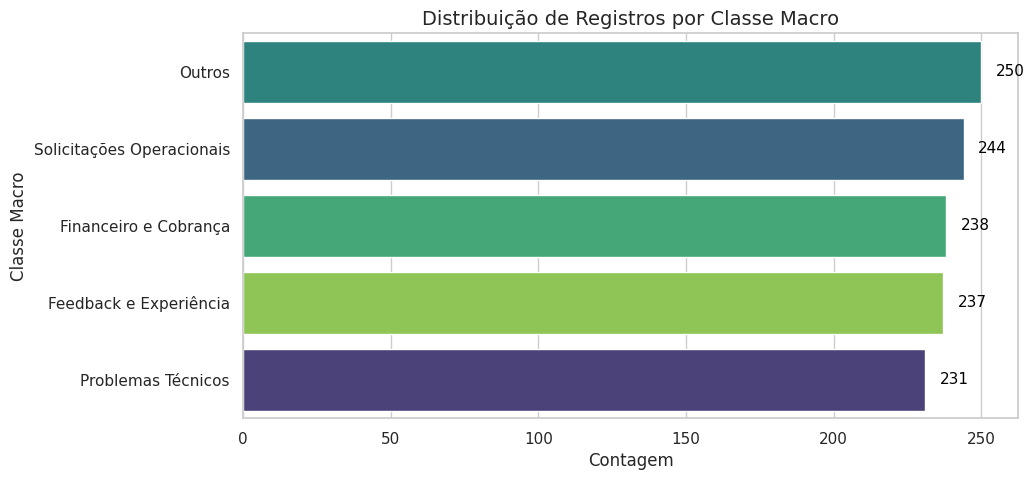

In [32]:
# Distribuição das Classes Macro
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, y='classe_macro', order=df['classe_macro'].value_counts().index, hue='classe_macro', legend=False, palette='viridis')
plt.title('Distribuição de Registros por Classe Macro', fontsize=14)
plt.xlabel('Contagem')
plt.ylabel('Classe Macro')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width() + 5, p.get_y() + p.get_height() / 2), 
                ha='left', va='center', fontsize=11, color='black')
plt.show()

> A distribuição das classes macro está balanceada. 

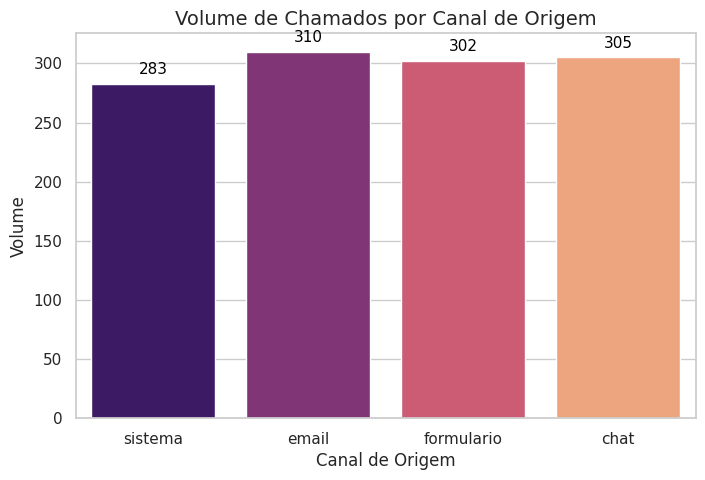

In [33]:
# Distribuição por Canal de Origem
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='canal_origem', hue='canal_origem', legend=False, palette='magma')
plt.title('Volume de Chamados por Canal de Origem', fontsize=14)
plt.xlabel('Canal de Origem')
plt.ylabel('Volume')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

> O volume entre os  canais **email, chat, formulário e sistema** é praticamente idêntico.

## 4. Relação entre Canal de Origem e Classe Macro
Verificamos se algum canal é desproporcionalmente usado para alguma classe.

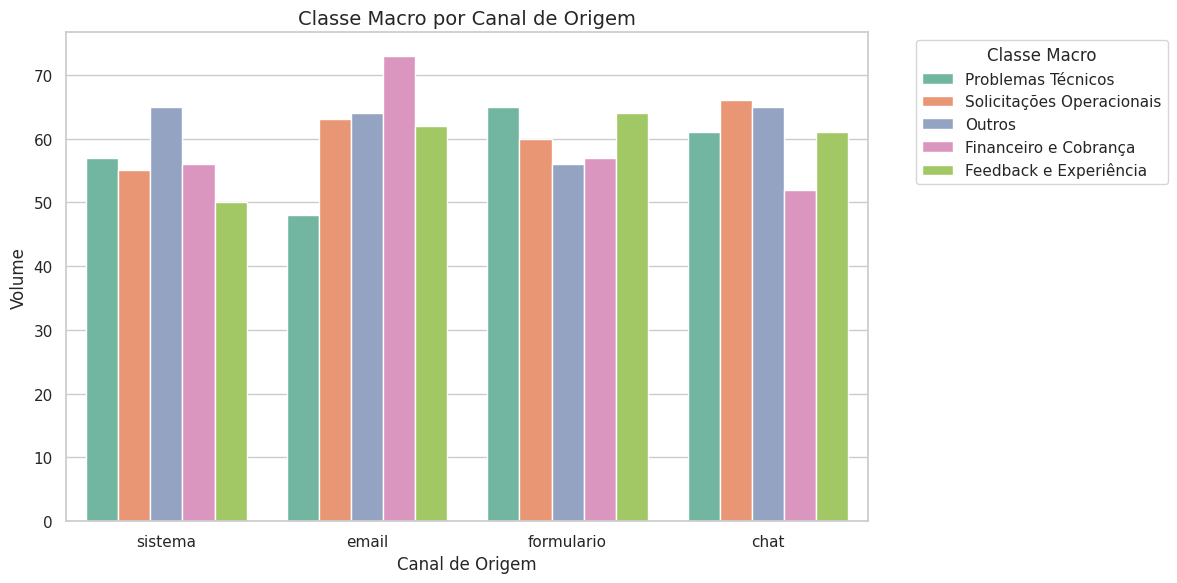

In [34]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='canal_origem', hue='classe_macro', palette='Set2')
plt.title('Classe Macro por Canal de Origem', fontsize=14)
plt.xlabel('Canal de Origem')
plt.ylabel('Volume')
plt.legend(title='Classe Macro', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> A distribuição de classe Macro dentro de cada canal é balanceada.

## 5. Análise de Frequência e Estrutura Textual

In [35]:
df['caracteres'] = df['texto'].str.len()
df['palavras'] = df['texto'].apply(lambda x: len(str(x).split()))

display(df[['caracteres', 'palavras']].describe())

,caracteres,palavras
count,1200.000000,1200.000000
mean,40.373333,5.644167
std,13.088037,2.323155
min,20.000000,2.000000
25%,31.000000,4.000000
50%,39.000000,5.000000
75%,47.000000,7.000000
max,95.000000,14.000000


/tmp/ipykernel_28887/1252826414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='palavras', y='classe_macro', palette='coolwarm')


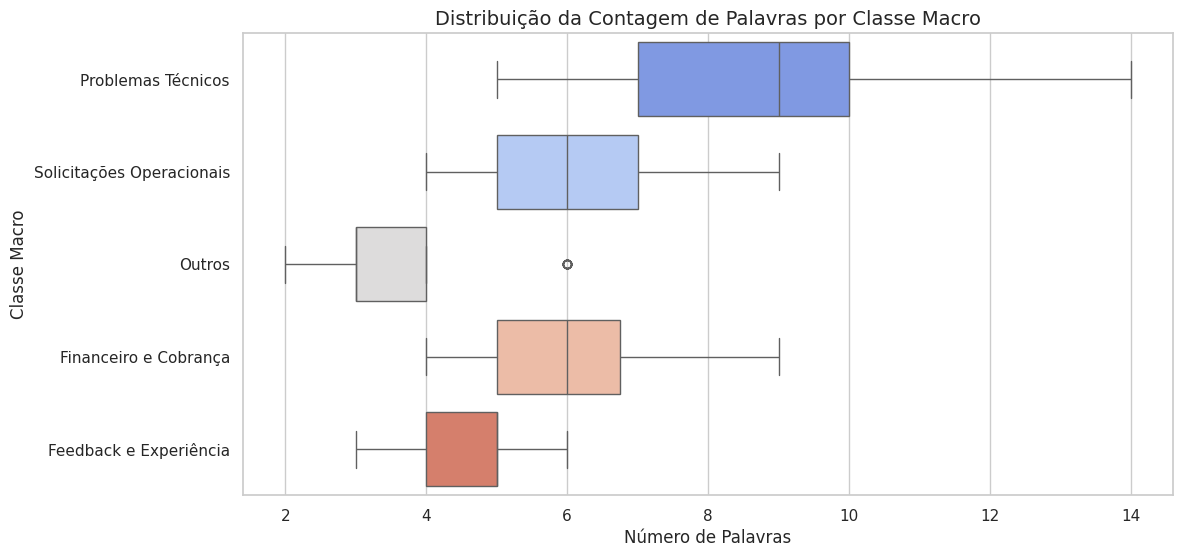

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='palavras', y='classe_macro', palette='coolwarm')
plt.title('Distribuição da Contagem de Palavras por Classe Macro', fontsize=14)
plt.xlabel('Número de Palavras')
plt.ylabel('Classe Macro')
plt.show()

>  A média de palavras é perto de 6 por chamado. As classes atreladas a *Problemas Técnicos* costumam conter textos maiores.

## 6. Bigramas (N-Grams)

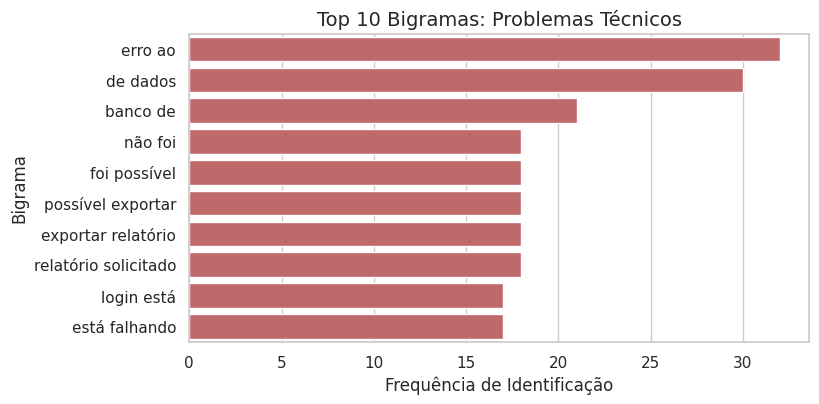

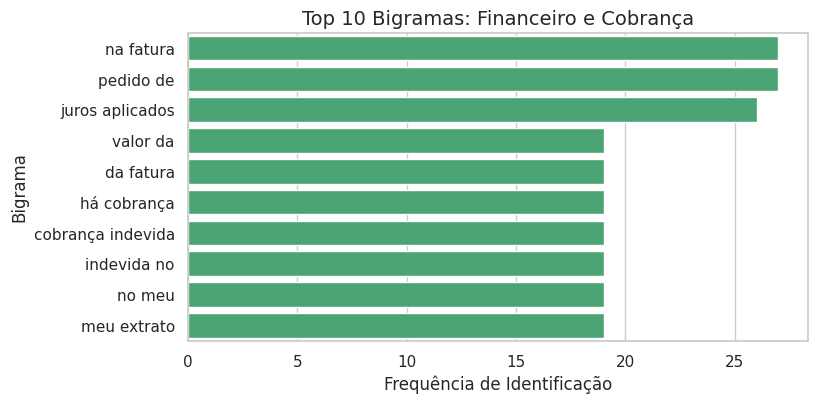

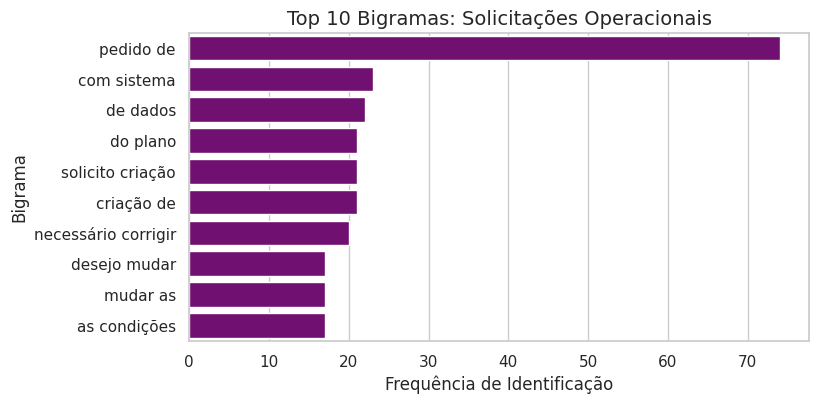

In [37]:
def plot_top_ngrams(corpus, title, n=2, color='blue'):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:10]
    
    x, y = zip(*words_freq)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(y), y=list(x), color=color)
    plt.title(title, fontsize=14)
    plt.xlabel('Frequência de Identificação')
    plt.ylabel('Bigrama')
    plt.show()

# Gerando e Plotando Bigramas para Classes-Chave
texto_problemas = df[df['classe_macro'] == 'Problemas Técnicos']['texto']
plot_top_ngrams(texto_problemas, "Top 10 Bigramas: Problemas Técnicos", n=2, color='indianred')

texto_financeiro = df[df['classe_macro'] == 'Financeiro e Cobrança']['texto']
plot_top_ngrams(texto_financeiro, "Top 10 Bigramas: Financeiro e Cobrança", n=2, color='mediumseagreen')

texto_operacionais = df[df['classe_macro'] == 'Solicitações Operacionais']['texto']
plot_top_ngrams(texto_operacionais, "Top 10 Bigramas: Solicitações Operacionais", n=2, color='purple')

> Análise semântica muito clara, 'erro ao' vs 'da fatura' vs 'pedido de'. O que indica que o TF-IDF será ideal para classificar.

## 7. Análise de Risco (Vazamento / Data Leakage)
Chamados exatamente iguais podem poluir a separação de Treino e Teste, inflando enganosamente a avaliação.

In [38]:
duplicadas_texto = df['texto'].duplicated().sum()
total_registros = len(df)
print(f"Volume de Textos Exatamente Duplicados: {duplicadas_texto}")
print(f"Representatividade de Duplicadas: {(duplicadas_texto/total_registros)*100:.2f}%")

if duplicadas_texto > 0:
    display(df[df.duplicated(subset=['texto'], keep=False)].sort_values(by='texto').head(4))

Volume de Textos Exatamente Duplicados: 1122
Representatividade de Duplicadas: 93.50%


,id_registro,texto,canal_origem,data,classe_macro,classe_detalhada,caracteres,palavras
773,774,A aplicação está fora do ar desde o início da ...,chat,2025-03-14,Problemas Técnicos,Indisponibilidade / Queda do Serviço,52,11
824,825,A aplicação está fora do ar desde o início da ...,formulario,2025-03-09,Problemas Técnicos,Indisponibilidade / Queda do Serviço,52,11
899,900,A aplicação está fora do ar desde o início da ...,formulario,2025-03-24,Problemas Técnicos,Indisponibilidade / Queda do Serviço,52,11
709,710,A aplicação está fora do ar desde o início da ...,chat,2025-03-13,Problemas Técnicos,Indisponibilidade / Queda do Serviço,52,11


> Uma taxa significativa de textos iguais foi encontrada. Esse é um grande exemplo de vazamento de dados, pois o modelo irá treinar e testar com o mesmo texto qo que resultará em uma falsa realidade

## Conclusões Finais 

1. **Sanidade dos Dados:** Dados estruturalmente balanceados e sem nulos.
2. **Extensão Textual:** Textos rápidos de curta duração. 
3. **Vocabulários Divergentes:** Separação vocabular propícia a modelos probabilísticos simples e vetoriais como TF-IDF com Random Forest ou Logistic Regression, gerando alta estabilidade e interpretabilidade preditiva.